# Explore here

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
 
# load the .env file variables
load_dotenv()



True

In [1]:
import requests

ip = requests.get("https://api64.ipify.org?format=json").json()["ip"]
print(f"Tu IP pública es: {ip}")

Tu IP pública es: 20.163.40.136


In [4]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import os
from dotenv import load_dotenv

# Cargar credenciales desde .env
load_dotenv()

sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id = os.getenv("SPOTIPY_CLIENT_ID"),
    client_secret = os.getenv("SPOTIPY_CLIENT_SECRET"),
    redirect_uri = "http://localhost:8888/callback",  # Ajusta si usas Ngrok
    scope="user-read-private user-read-email"
))

print("Conectado a la API de Spotify correctamente.")

Conectado a la API de Spotify correctamente.


In [6]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

auth_manager = SpotifyClientCredentials(client_id="SPOTIPY_CLIENT_ID", client_secret="SPOTIPY_CLIENT_SECRET")
spotify = spotipy.Spotify(auth_manager=auth_manager)

In [10]:
artist_id = "3TVXtAsR1Inumwj472S9r4"

# Obtener las mejores canciones del artista (de EE.UU.)
results = spotify.artist_top_tracks(artist_id, country="US")

songs = []
for track in results['tracks']:
    songs.append({
        'name': track['name'],
        'popularity': track['popularity'],
        'duration_min': track['duration_ms'] / 60000
    })

print(songs)

[{'name': 'NOKIA', 'popularity': 94, 'duration_min': 4.01705}, {'name': 'One Dance', 'popularity': 88, 'duration_min': 2.899766666666667}, {'name': 'DIE TRYING', 'popularity': 88, 'duration_min': 3.2571833333333333}, {'name': 'She Will', 'popularity': 82, 'duration_min': 5.097333333333333}, {'name': 'Passionfruit', 'popularity': 86, 'duration_min': 4.982333333333333}, {'name': "God's Plan", 'popularity': 85, 'duration_min': 3.3162166666666666}, {'name': 'WAIT FOR U (feat. Drake & Tems)', 'popularity': 85, 'duration_min': 3.1648833333333335}, {'name': 'Headlines', 'popularity': 84, 'duration_min': 3.9331}, {'name': 'Jimmy Cooks (feat. 21 Savage)', 'popularity': 82, 'duration_min': 3.6394}, {'name': 'SOMEBODY LOVES ME', 'popularity': 82, 'duration_min': 3.046116666666667}]


In [13]:
tracks_df = pd.DataFrame(songs)

print(tracks_df.head(3))

         name  popularity  duration_min
0       NOKIA          94      4.017050
1   One Dance          88      2.899767
2  DIE TRYING          88      3.257183


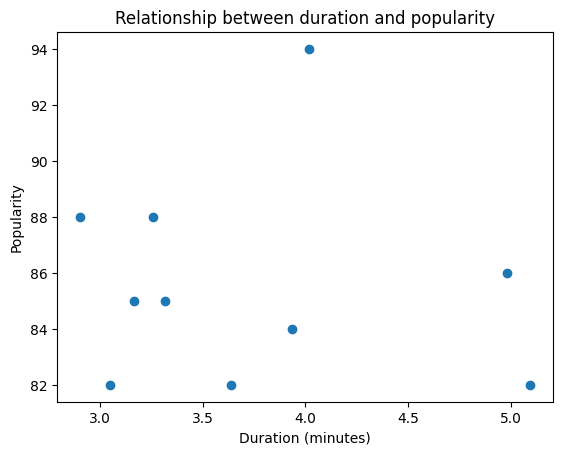

In [17]:
import matplotlib.pyplot as plt

plt.scatter(tracks_df['duration_min'], tracks_df['popularity'])
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity')
plt.title('Relationship between duration and popularity')
plt.show()

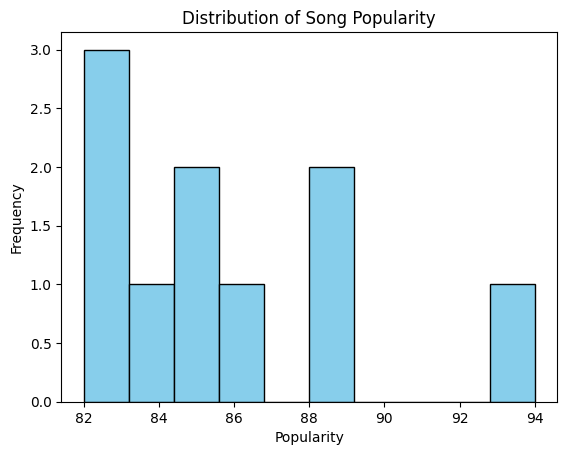

In [18]:
import matplotlib.pyplot as plt

plt.hist(tracks_df['popularity'], bins=10, color="skyblue", edgecolor="black")
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Song Popularity')

plt.show()

## *7 Realiza una relacion estadistica*

In [19]:
import pandas as pd

# Calcular la correlación entre duración y popularidad
correlation = tracks_df[['duration_min', 'popularity']].corr()

print("Correlación entre duración y popularidad:")
print(correlation)

Correlación entre duración y popularidad:
              duration_min  popularity
duration_min      1.000000   -0.080223
popularity       -0.080223    1.000000
